In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv('data/HR/train.csv',nrows=1000)
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [76]:
df.isnull().sum()

employee_id              0
department               0
region                   0
education               49
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating    86
length_of_service        0
awards_won?              0
avg_training_score       0
is_promoted              0
dtype: int64

In [77]:
df['previous_year_rating'] = df['previous_year_rating'].fillna(0,inplace=True)

/tmp/ipykernel_2398056/3828530509.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['previous_year_rating'] = df['previous_year_rating'].fillna(0,inplace=True)


In [78]:
df['education'] = df['education'].fillna('missing', inplace=True)

/tmp/ipykernel_2398056/3013849452.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['education'] = df['education'].fillna('missing', inplace=True)


In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df.drop_duplicates(inplace=True)

In [81]:
df.shape

(1000, 13)

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           1000 non-null   int64  
 1   department            1000 non-null   str    
 2   region                1000 non-null   str    
 3   education             1000 non-null   str    
 4   gender                1000 non-null   str    
 5   recruitment_channel   1000 non-null   str    
 6   no_of_trainings       1000 non-null   int64  
 7   age                   1000 non-null   int64  
 8   previous_year_rating  1000 non-null   float64
 9   length_of_service     1000 non-null   int64  
 10  awards_won?           1000 non-null   int64  
 11  avg_training_score    1000 non-null   int64  
 12  is_promoted           1000 non-null   int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 101.7 KB


In [83]:
target = df['is_promoted']

In [84]:
df = df.drop(['employee_id','is_promoted'], axis=1)

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder ,MinMaxScaler, OrdinalEncoder, PowerTransformer

#Categorical columns department, region, education, gender, recruitment_channel need encoding. region by Target Encoding,
#  Department/gender by OHE. Numerical columns age, length_of_service, avg_training_score, no_of_trainings already good range, can standardize later.

processor = ColumnTransformer(
    transformers=[
        ('pw', PowerTransformer(method='yeo-johnson'), ['length_of_service']),
        ('num', MinMaxScaler(), ['age', 'avg_training_score']),
        ('target', TargetEncoder(), ['region']),
        ('cat', OneHotEncoder(), ['department', 'gender', 'recruitment_channel']),
        ('ordinal', OrdinalEncoder(categories=[[ 'missing','Below Secondary', 'Bachelor\'s', 'Master\'s & above']]), ['education'])
    ],
    remainder='passthrough'
)

In [86]:
df_proccessed = processor.fit_transform(df,target)

In [87]:
df = pd.DataFrame(df_proccessed,index=df.index,columns=processor.get_feature_names_out())

## KMEANS

In [88]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2)

labels = model.fit_predict(df)
print(labels)

[0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 1 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0
 0 1 0 1 1 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0
 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0
 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0
 0 0 0 1 0 1 0 0 1 0 0 1 

In [89]:
df.columns

Index(['pw__length_of_service', 'num__age', 'num__avg_training_score',
       'target__region', 'cat__department_Analytics',
       'cat__department_Finance', 'cat__department_HR',
       'cat__department_Legal', 'cat__department_Operations',
       'cat__department_Procurement', 'cat__department_R&D',
       'cat__department_Sales & Marketing', 'cat__department_Technology',
       'cat__gender_f', 'cat__gender_m', 'cat__recruitment_channel_other',
       'cat__recruitment_channel_referred',
       'cat__recruitment_channel_sourcing', 'ordinal__education',
       'remainder__no_of_trainings', 'remainder__previous_year_rating',
       'remainder__awards_won?'],
      dtype='str')

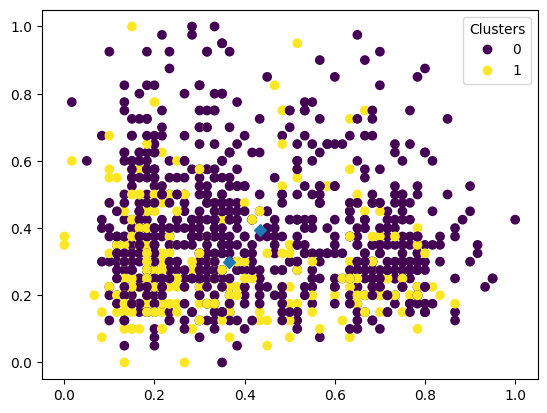

In [90]:
ys = df['num__age']
xs = df['num__avg_training_score']

scatter = plt.scatter(xs, ys, c=labels, cmap='viridis')

# Create legend
plt.legend(*scatter.legend_elements(), title="Clusters")
centroids=model.cluster_centers_
centroids_x=centroids[:,2]
centroids_y=centroids[:,1]
plt.scatter(centroids_x,centroids_y,marker='D')
plt.show()

## KMEANS++

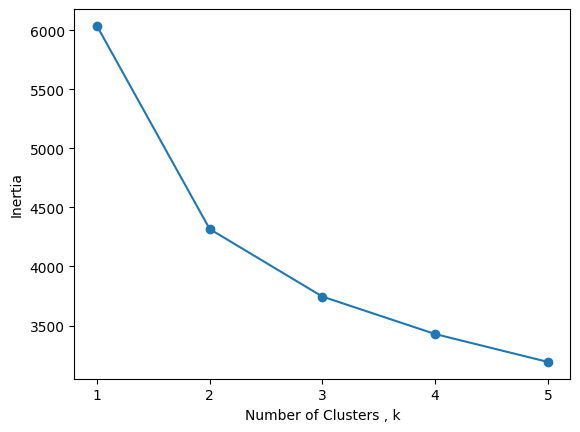

In [91]:
ks=range(1,6)
inertias=[]

for k in ks:
    model=KMeans(n_clusters=k)
    model.fit(df)
    inertias.append(model.inertia_)

plt.plot(ks,inertias,'-o')
plt.xlabel('Number of Clusters , k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.show()

### Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(df,labels)

## DBSCAN

In [93]:
from sklearn.cluster import DBSCAN

model = DBSCAN()

labels = model.fit_predict(df)

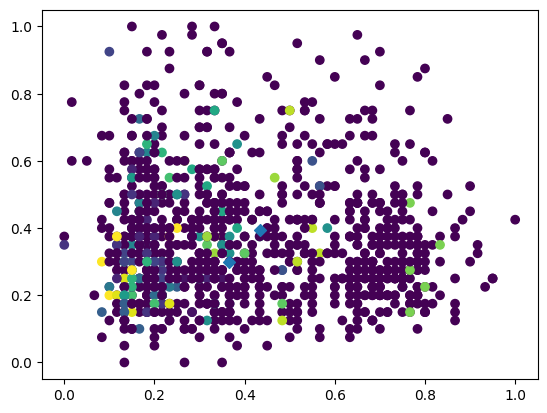

In [94]:
ys = df['num__age']
xs = df['num__avg_training_score']
plt.scatter(xs,ys,c=labels)
plt.scatter(centroids_x,centroids_y,marker='D')
plt.show()

## AGGLOMERATIVE

In [95]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering()

labels = model.fit_predict(df)

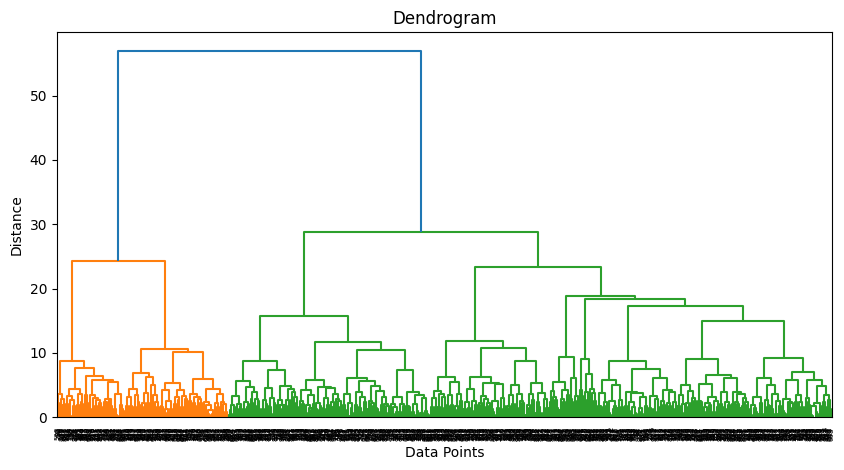

In [96]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


In [97]:
from sklearn.metrics import silhouette_score
silhouette_score(df,labels)

0.284937092241006

## PCA

In [ ]:
from sklearn.decomposition import PCA

model = PCA(n_components=2)

pca = PCA(n_components=2)   
X_pca = pca.fit_transform(df)

In [101]:
print(pca.explained_variance_ratio_)

[0.4199291 0.1448315]


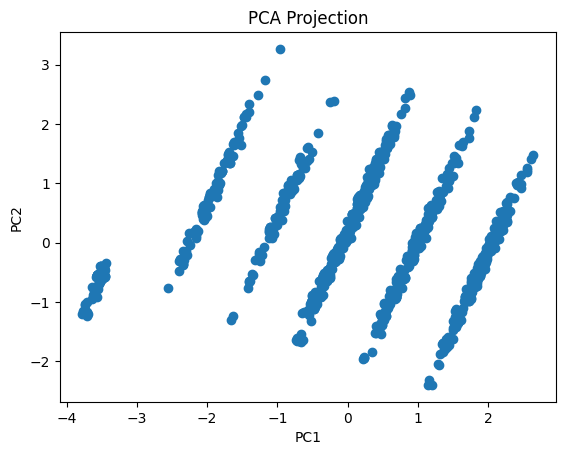

In [102]:

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

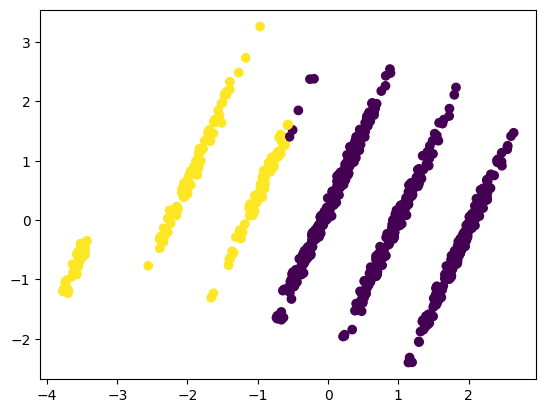

In [103]:
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.show()

In [104]:
silhouette_score(X_pca,labels)

0.4854411338242809